In [1]:
import pandas as pd

In [2]:
df=pd.read_csv("amz_uk_price_prediction_dataset.csv")

In [3]:
df.head()

,uid,asin,title,stars,reviews,price,isBestSeller,boughtInLastMonth,category
0,1,B09B96TG33,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
1,2,B01HTH3C8S,"Anker Soundcore mini, Super-Portable Bluetooth...",4.7,98099,23.99,True,0,Hi-Fi Speakers
2,3,B09B8YWXDF,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
3,4,B09B8T5VGV,"Echo Dot with clock (5th generation, 2022 rele...",4.7,7205,31.99,False,0,Hi-Fi Speakers
4,5,B09WX6QD65,Introducing Echo Pop | Full sound compact Wi-F...,4.6,1881,17.99,False,0,Hi-Fi Speakers



**Crosstab Analysis**:
    - Create a crosstab between the product `category` and the `isBestSeller` status.
    
    - Are there categories where being a best-seller is more prevalent? 
    	
    	*Hint: one option is to calculate the proportion of best-sellers for each category and then sort the categories based on this proportion in descending order.*

In [4]:
crosstab = pd.crosstab(df['category'], df['isBestSeller'])
print(crosstab)

isBestSeller                    False  True 
category                                    
3D Printers                       247      1
3D Printing & Scanning           4065      2
Abrasive & Finishing Products     245      5
Action Cameras                   1696      1
Adapters                          251      3
...                               ...    ...
Wind Instruments                  243      7
Window Treatments                 234      5
Women                           17559    213
Women's Sports & Outdoor Shoes   1939     20
eBook Readers & Accessories       246      0

[296 rows x 2 columns]


In [5]:
crosstab['total'] = crosstab.sum(axis=1)

crosstab['bestseller_ratio'] = crosstab[True] / crosstab['total']

print(crosstab)

isBestSeller                    False  True  total  bestseller_ratio
category                                                            
3D Printers                       247     1    248          0.004032
3D Printing & Scanning           4065     2   4067          0.000492
Abrasive & Finishing Products     245     5    250          0.020000
Action Cameras                   1696     1   1697          0.000589
Adapters                          251     3    254          0.011811
...                               ...   ...    ...               ...
Wind Instruments                  243     7    250          0.028000
Window Treatments                 234     5    239          0.020921
Women                           17559   213  17772          0.011985
Women's Sports & Outdoor Shoes   1939    20   1959          0.010209
eBook Readers & Accessories       246     0    246          0.000000

[296 rows x 4 columns]


In [6]:
sorted_categories = crosstab.sort_values(by='bestseller_ratio', ascending=False)

print(sorted_categories[['bestseller_ratio']])

isBestSeller                      bestseller_ratio
category                                          
Grocery                                   0.058135
Smart Home Security & Lighting            0.057692
Health & Personal Care                    0.057686
Mobile Phone Accessories                  0.042471
Power & Hand Tools                        0.035339
...                                            ...
CD, Disc & Tape Players                   0.000000
General Music-Making Accessories          0.000000
Snowboard Boots                           0.000000
Boxes & Organisers                        0.000000
eBook Readers & Accessories               0.000000

[296 rows x 1 columns]


Here are top categories which tend to be bestsellers

2. **Statistical Tests**:
    - Conduct a Chi-square test to determine if the best-seller distribution is independent of the product category.
    - Compute Cramér's V to understand the strength of association between best-seller status and category.

In [7]:
from scipy.stats import chi2_contingency
table = pd.crosstab(df['category'], df['isBestSeller'])
chi2, p, dof, expected = chi2_contingency(table)

print("Chi-square:", chi2)
print("p-value:", p)
print("Degrees of freedom:", dof)

Chi-square: 36540.20270061387
p-value: 0.0
Degrees of freedom: 295


P value is 0 that means some relation exsist between variable

In [8]:
import numpy as np

n = table.sum().sum()

cramers_v = np.sqrt(chi2 / (n * (min(table.shape) - 1)))

print("Cramer's V:", cramers_v)

Cramer's V: 0.1222829439760564


cramer value 0.12 that  means relation is weak.

**Visualizations**:
	- Visualize the relationship between product categories and the best-seller status using a stacked bar chart.


In [9]:
ct = pd.crosstab(df['category'], df['isBestSeller'])

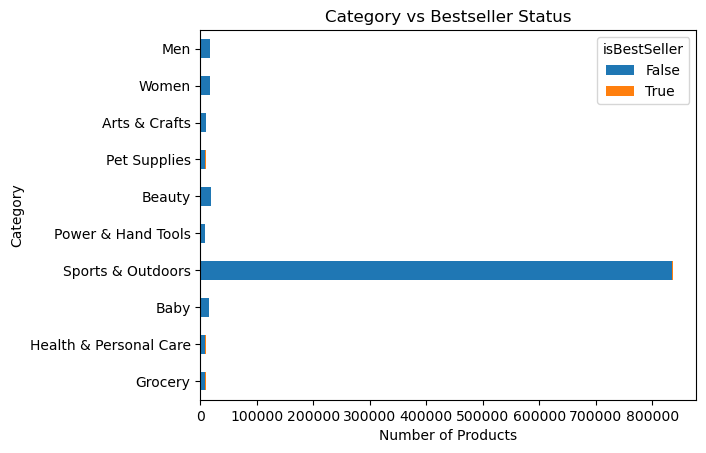

In [12]:
ct_top.plot(kind='barh', stacked=True)

plt.title('Category vs Bestseller Status')
plt.xlabel('Number of Products')
plt.ylabel('Category')

plt.show()

For this purpose, we can use the IQR (Interquartile Range) method. Products priced below the first quartile minus 1.5 times the IQR or above the third quartile plus 1.5 times the IQR will be considered outliers and removed from the dataset. The next steps will be done with the dataframe without outliers.
	
	*Hint: you can check the last Check For Understanding at the end of the lesson EDA Bivariate Analysis for a hint on how to do this.*


In [13]:
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)

IQR = Q3 - Q1

In [14]:
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

In [15]:
df_no_outliers = df[(df['price'] >= lower_bound) & (df['price'] <= upper_bound)]

**Violin Plots**:
    - Use a violin plot to visualize the distribution of `price` across different product `categories`. Filter out the top 20 categories based on count for better visualization.
    - Which product category tends to have the highest median price? Don't filter here by top categories.


In [16]:
top_categories = df['category'].value_counts().head(20).index

In [17]:
df_top = df[df['category'].isin(top_categories)]

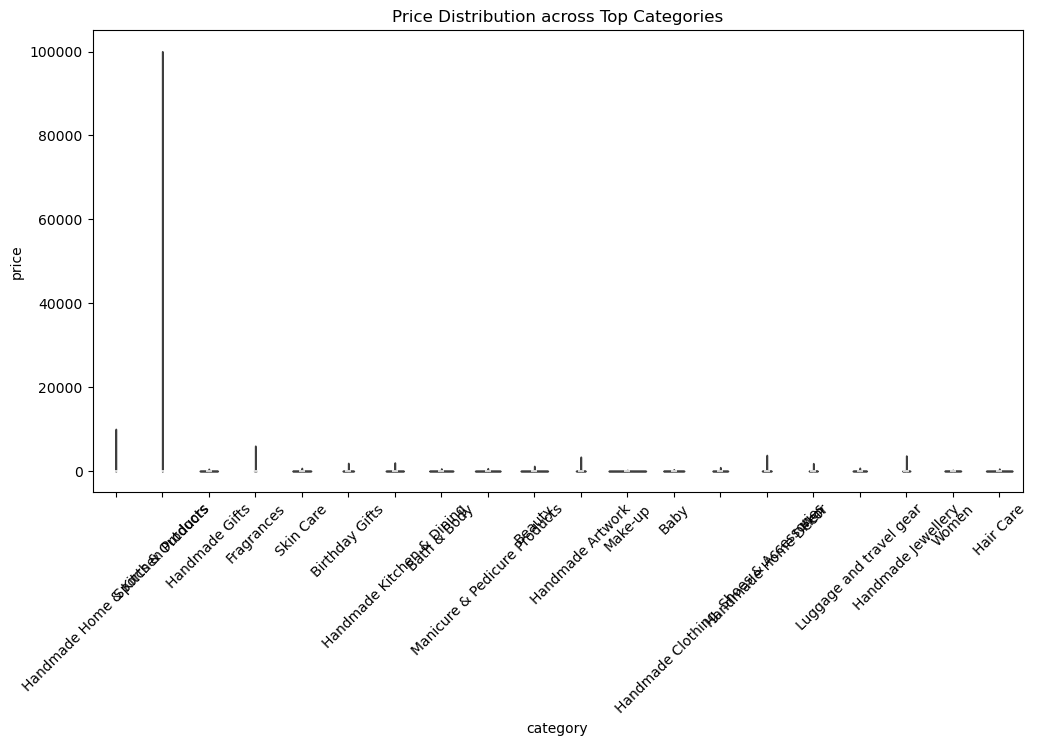

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

sns.violinplot(x='category', y='price', data=df_top)

plt.xticks(rotation=45)
plt.title('Price Distribution across Top Categories')

plt.show()

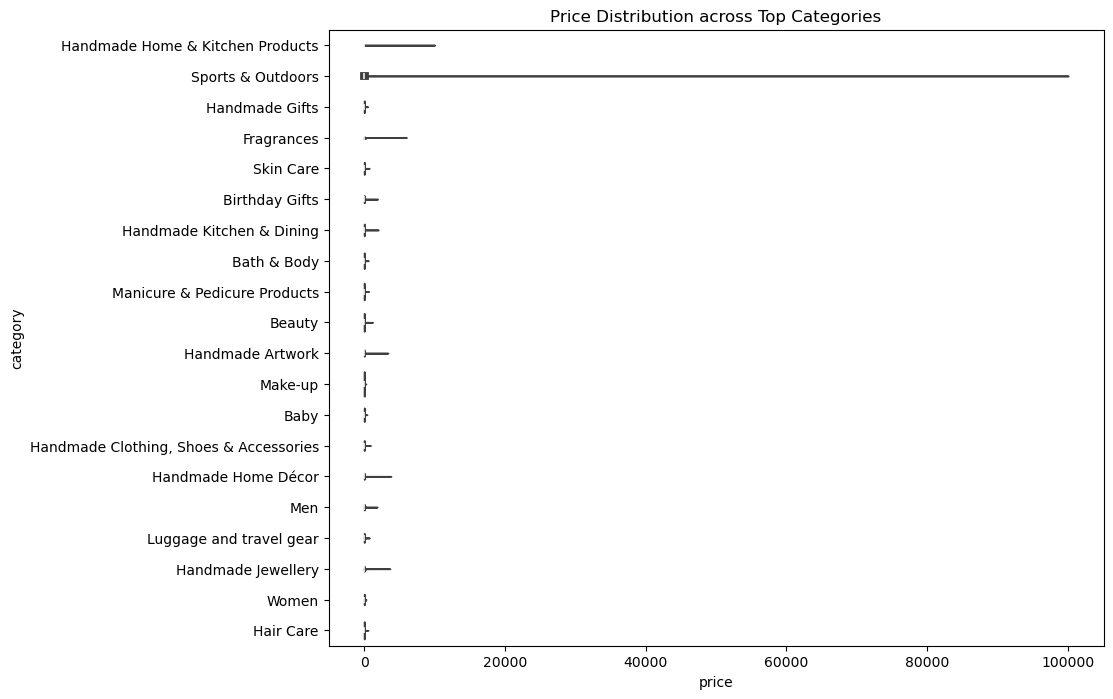

In [19]:
plt.figure(figsize=(10,8))

sns.violinplot(y='category', x='price', data=df_top)

plt.title('Price Distribution across Top Categories')

plt.show()